# 03 — H2b: Relative Growth of Evidence-Based Treatment Searches (EBT Ratio)

**Hypothesis H2b:** The share of evidence-based treatment searches relative to general psychological help searches shows a significant positive trend over time, reflecting a qualitative shift in user awareness.

**Method:** OLS linear trend analysis (primary). If assumptions violated → Mann-Kendall trend test (fallback).

**OSF pre-registration:** https://osf.io/7986u

---

**Outcome variable (per OSF protocol — Indices section):**

```
EBT_ratio(country, month) =
    mean(search_interest[evidence_based_treatments keywords]) /
    mean(search_interest[general_help_seeking keywords])
```

If denominator = 0 → observation excluded (NaN).

**Model:** Y(t) = β0 + β1·time + ε  
**H2b confirmed if:** β1 > 0 AND p < 0.017 (Bonferroni-corrected α)

## 0. Setup

In [1]:
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats
import pymannkendall as mk
from pathlib import Path

warnings.filterwarnings('ignore')

DATA_DIR   = Path('../data')
OUTPUT_DIR = Path('../results/H2b')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Two categories needed: EBT (numerator) and general help-seeking (denominator)
CAT_EBT     = 'evidence_based_treatments'
CAT_GENERAL = 'general_help_seeking'
ALPHA       = 0.05
ALPHA_BONF  = ALPHA / 3    # Bonferroni: 3 hypotheses tested simultaneously
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

print(f'EBT category:     {CAT_EBT}')
print(f'General category: {CAT_GENERAL}')
print(f'Alpha (corrected): {ALPHA_BONF:.3f}')


EBT category:     evidence_based_treatments
General category: general_help_seeking
Alpha (corrected): 0.017


## 1. Load data

For each country: load both categories, compute monthly mean per category, then compute EBT ratio.

In [2]:
def load_country_category(country_dir: Path, category: str) -> pd.Series | None:
    """
    Load all CSV files for a given country and category.
    Returns monthly mean RSV across all keywords and languages (pd.Series).
    Returns None if no valid data found.
    """
    csv_files = sorted(country_dir.glob(f'{category}__*__chunk*.csv'))
    if not csv_files:
        return None

    frames = []
    for f in csv_files:
        try:
            df = pd.read_csv(f, parse_dates=['date'], index_col='date')
            if 'isPartial' in df.columns:
                df = df[df['isPartial'] == False].drop(columns=['isPartial'])
            df = df.replace(0, np.nan)       # 0 = below detection threshold, not true zero
            all_nan_cols = df.columns[df.isna().all()]
            df = df.drop(columns=all_nan_cols)
            if df.empty or df.shape[1] == 0:
                continue
            frames.append(df)
        except Exception as e:
            print(f'  Warning: {f.name}: {e}')

    if not frames:
        return None

    combined = pd.concat(frames, axis=1)
    return combined.mean(axis=1)   # one RSV value per month for this country+category


raw_folders = sorted(DATA_DIR.glob('raw_*'))
if not raw_folders:
    raise FileNotFoundError(f'No raw_* folders found in {DATA_DIR}')
LATEST = raw_folders[-1]
print(f'Data folder: {LATEST.name}')

# Load BOTH categories for every country — both are needed to compute the ratio
ebt_series     = {}   # country → monthly mean EBT RSV
general_series = {}   # country → monthly mean general help-seeking RSV
missing_report = {}

country_dirs = sorted([d for d in LATEST.iterdir() if d.is_dir()])

for country_dir in country_dirs:
    code_ = country_dir.name
    s_ebt = load_country_category(country_dir, CAT_EBT)
    s_gen = load_country_category(country_dir, CAT_GENERAL)

    # Country is excluded if EITHER category is missing — ratio requires both
    if s_ebt is None:
        missing_report[code_] = 'No EBT data'
        continue
    if s_gen is None:
        missing_report[code_] = 'No general_help_seeking data'
        continue

    ebt_series[code_]     = s_ebt
    general_series[code_] = s_gen

print(f'Countries loaded: {len(ebt_series)}')
if missing_report:
    print('Excluded:')
    for c, reason in missing_report.items():
        print(f'  {c}: {reason}')


Data folder: raw_20260417_211800
Countries loaded: 21


## 2. Compute EBT ratio per country per month

Per OSF protocol:
```
EBT_ratio = mean(EBT keywords) / mean(general keywords)
```
If denominator = 0 → NaN.

In [3]:
ratio_series  = {}
ratio_missing = {}

for code_ in ebt_series:
    s_ebt = ebt_series[code_]
    s_gen = general_series[code_]

    # Align on common dates — EBT and general series may have slightly different date ranges
    s_ebt, s_gen = s_ebt.align(s_gen, join='inner')

    # EBT ratio = EBT mean / general mean (per OSF protocol)
    # Denominator = 0 → NaN (excluded from analysis, not treated as infinite)
    ratio = s_ebt / s_gen.replace(0, np.nan)

    pct_missing = ratio.isna().mean()
    if pct_missing > 0.20:
        ratio_missing[code_] = f'Ratio missing > 20% ({pct_missing:.1%})'
        continue

    ratio_series[code_] = ratio

print(f'Countries with valid ratio: {len(ratio_series)}')
if ratio_missing:
    print('Excluded from ratio:')
    for c, reason in ratio_missing.items():
        print(f'  {c}: {reason}')

panel_ratio = pd.DataFrame(ratio_series)
panel_ratio.index = pd.to_datetime(panel_ratio.index)
panel_ratio = panel_ratio.sort_index()

# Global mean ratio across countries per month — outcome variable Y(t) for H2b
y_global = panel_ratio.mean(axis=1)
t = np.arange(len(y_global))

print(f'\nTime range: {y_global.index[0].date()} → {y_global.index[-1].date()}')
print(f'N months:   {len(y_global)}')
print(f'N countries: {panel_ratio.shape[1]}')
print(f'\nGlobal mean EBT ratio: {y_global.mean():.4f} (SD={y_global.std():.4f})')
print(f'Missing values: {y_global.isna().sum()}')


Countries with valid ratio: 15
Excluded from ratio:
  AM: Ratio missing > 20% (91.7%)
  AZ: Ratio missing > 20% (86.5%)
  EE: Ratio missing > 20% (75.0%)
  GE: Ratio missing > 20% (63.5%)
  MD: Ratio missing > 20% (62.5%)
  UZ: Ratio missing > 20% (39.6%)

Time range: 2018-01-01 → 2025-12-01
N months:   96
N countries: 15

Global mean EBT ratio: 2.4891 (SD=0.4440)
Missing values: 0


## 3. OLS linear trend model

In [10]:
mask  = ~y_global.isna()


## 4. Assumption checks

In [12]:
y_ols = y_global[mask].values
t_ols = t[mask]

X     = sm.add_constant(t_ols)
model = sm.OLS(y_ols, X).fit()

beta0 = model.params[0]
beta1 = model.params[1]
p_val = model.pvalues[1]
r2    = model.rsquared
ci    = model.conf_int()

print('OLS — EBT Ratio Trend')
print('-' * 40)
print(f'β0 (intercept): {beta0:.6f}')
print(f'β1 (trend):     {beta1:.6f}')
print(f'p-value:        {p_val:.4f}')
print(f'R²:             {r2:.4f}')
sig = p_val < ALPHA_BONF and beta1 > 0
print(f'\nH2b (OLS): {"SUPPORTED" if sig else "NOT SUPPORTED"}')

OLS — EBT Ratio Trend
----------------------------------------
β0 (intercept): 2.575357
β1 (trend):     -0.001817
p-value:        0.2688
R²:             0.0130

H2b (OLS): NOT SUPPORTED


In [13]:
residuals = model.resid

sw_stat, sw_p = stats.shapiro(residuals)
normality_ok  = sw_p >= ALPHA

bp_stat, bp_p, _, _ = het_breuschpagan(residuals, X)
homoscedasticity_ok = bp_p >= ALPHA

print('Assumption Checks')
print('-' * 40)
print(f'Shapiro-Wilk (normality):')
print(f'  W={sw_stat:.4f}, p={sw_p:.4f}  → {"OK" if normality_ok else "VIOLATED"}')
print()
print(f'Breusch-Pagan (homoscedasticity):')
print(f'  stat={bp_stat:.4f}, p={bp_p:.4f}  → {"OK" if homoscedasticity_ok else "VIOLATED"}')

assumptions_ok = normality_ok and homoscedasticity_ok
print()
if assumptions_ok:
    print('✓ Both assumptions met — OLS results are valid.')
else:
    print('⚠ Assumptions violated — Mann-Kendall fallback will be used.')

Assumption Checks
----------------------------------------
Shapiro-Wilk (normality):
  W=0.9683, p=0.0200  → VIOLATED

Breusch-Pagan (homoscedasticity):
  stat=1.2508, p=0.2634  → OK

⚠ Assumptions violated — Mann-Kendall fallback will be used.


## 5. Mann-Kendall fallback

In [14]:
mk_result = mk.original_test(y_ols)

print('Mann-Kendall Trend Test — EBT Ratio')
print('-' * 40)
print(f'Trend:    {mk_result.trend}')
print(f'Tau (τ):  {mk_result.Tau:.4f}')
print(f'p-value:  {mk_result.p:.4f}')
print(f'z:        {mk_result.z:.4f}')
print()
mk_sig = '✓ SIGNIFICANT' if (mk_result.p < ALPHA_BONF and mk_result.trend == 'increasing') else '✗ NOT significant'
print(f'H2b result (MK): {mk_sig}')
print()
print('─' * 40)
if assumptions_ok:
    print('PRIMARY METHOD: OLS')
else:
    print('PRIMARY METHOD: Mann-Kendall (OLS assumptions violated)')

Mann-Kendall Trend Test — EBT Ratio
----------------------------------------
Trend:    no trend
Tau (τ):  -0.1035
p-value:  0.1360
z:        -1.4908

H2b result (MK): ✗ NOT significant

────────────────────────────────────────
PRIMARY METHOD: Mann-Kendall (OLS assumptions violated)


## 5b. Sensitivity — Google Trends 2022 artifact check

Same concern as H2a. For the EBT **ratio**, the artifact partially self-corrects
because both numerator (EBT) and denominator (general help-seeking) are affected
similarly by the Google Trends change. Nevertheless, a pre-2022 sensitivity is
reported for completeness and transparency.


In [15]:
# ── Google Trends 2022 artifact — sensitivity analysis ────────────────────────
# Google Trends updated its sampling methodology effective 1 January 2022,
# resulting in systematically higher RSV values from that date (Myburgh, 2022).
#
# For H2b (EBT ratio): the artifact affects BOTH numerator (EBT) and denominator
# (general_help_seeking) similarly, so the ratio may be partially self-correcting.
# Nevertheless, a pre-2022 sensitivity check is reported for completeness.
#
# Sensitivity: re-run ratio OLS and Mann-Kendall using ONLY pre-2022 data.

PRE_2022_END = pd.Timestamp('2021-12-31')

y_pre = y_global[y_global.index <= PRE_2022_END]
t_pre = np.arange(len(y_pre))

mask_pre  = ~y_pre.isna()
y_ols_pre = y_pre[mask_pre].values
t_ols_pre = t_pre[mask_pre]

# OLS — pre-2022
X_pre     = sm.add_constant(t_ols_pre)
model_pre = sm.OLS(y_ols_pre, X_pre).fit()
beta1_pre = model_pre.params[1]
p_val_pre = model_pre.pvalues[1]
r2_pre    = model_pre.rsquared

# Mann-Kendall — pre-2022
mk_pre = mk.original_test(y_ols_pre)

print('Google Trends 2022 Artifact — Sensitivity Analysis')
print('Period: 2018–2021 only (pre-GT-methodology-change)')
print('Note: ratio partially self-correcting (both components affected)')
print('=' * 60)
print(f'N months (pre-2022): {len(y_ols_pre)}')
print()
print('OLS:')
print(f'  β1 (trend):  {beta1_pre:.6f}  p={p_val_pre:.4f}  R²={r2_pre:.4f}')
sig_pre = p_val_pre < ALPHA_BONF and beta1_pre > 0
print(f'  H2b (pre-2022): {"SUPPORTED" if sig_pre else "NOT SUPPORTED"}')
print()
print('Mann-Kendall:')
print(f'  trend={mk_pre.trend}  τ={mk_pre.Tau:.4f}  p={mk_pre.p:.4f}')
print()

full_sig     = (p_val < ALPHA_BONF and beta1 > 0)
direction_ok = (beta1 > 0) == (beta1_pre > 0)

print('Consistency with full-period results:')
print(f'  Direction consistent: {"✓" if direction_ok else "✗  DIFFERS"}')
print(f'  Full period significant: {full_sig}')
print(f'  Pre-2022 significant:    {sig_pre}')
if full_sig and sig_pre:
    print('  → ✓ Robust: trend significant in both periods')
elif full_sig and not sig_pre:
    print('  → ⚠ Caution: trend significant only in full period')
    print('    (post-2022 GT artifact may contribute despite ratio self-correction)')
else:
    print('  → Neither period shows significant trend')


Google Trends 2022 Artifact — Sensitivity Analysis
Period: 2018–2021 only (pre-GT-methodology-change)
Note: ratio partially self-correcting (both components affected)
N months (pre-2022): 48

OLS:
  β1 (trend):  0.008174  p=0.1133  R²=0.0536
  H2b (pre-2022): NOT SUPPORTED

Mann-Kendall:
  trend=no trend  τ=0.1507  p=0.1331

Consistency with full-period results:
  Direction consistent: ✗  DIFFERS
  Full period significant: False
  Pre-2022 significant:    False
  → Neither period shows significant trend


## 6. Visualization

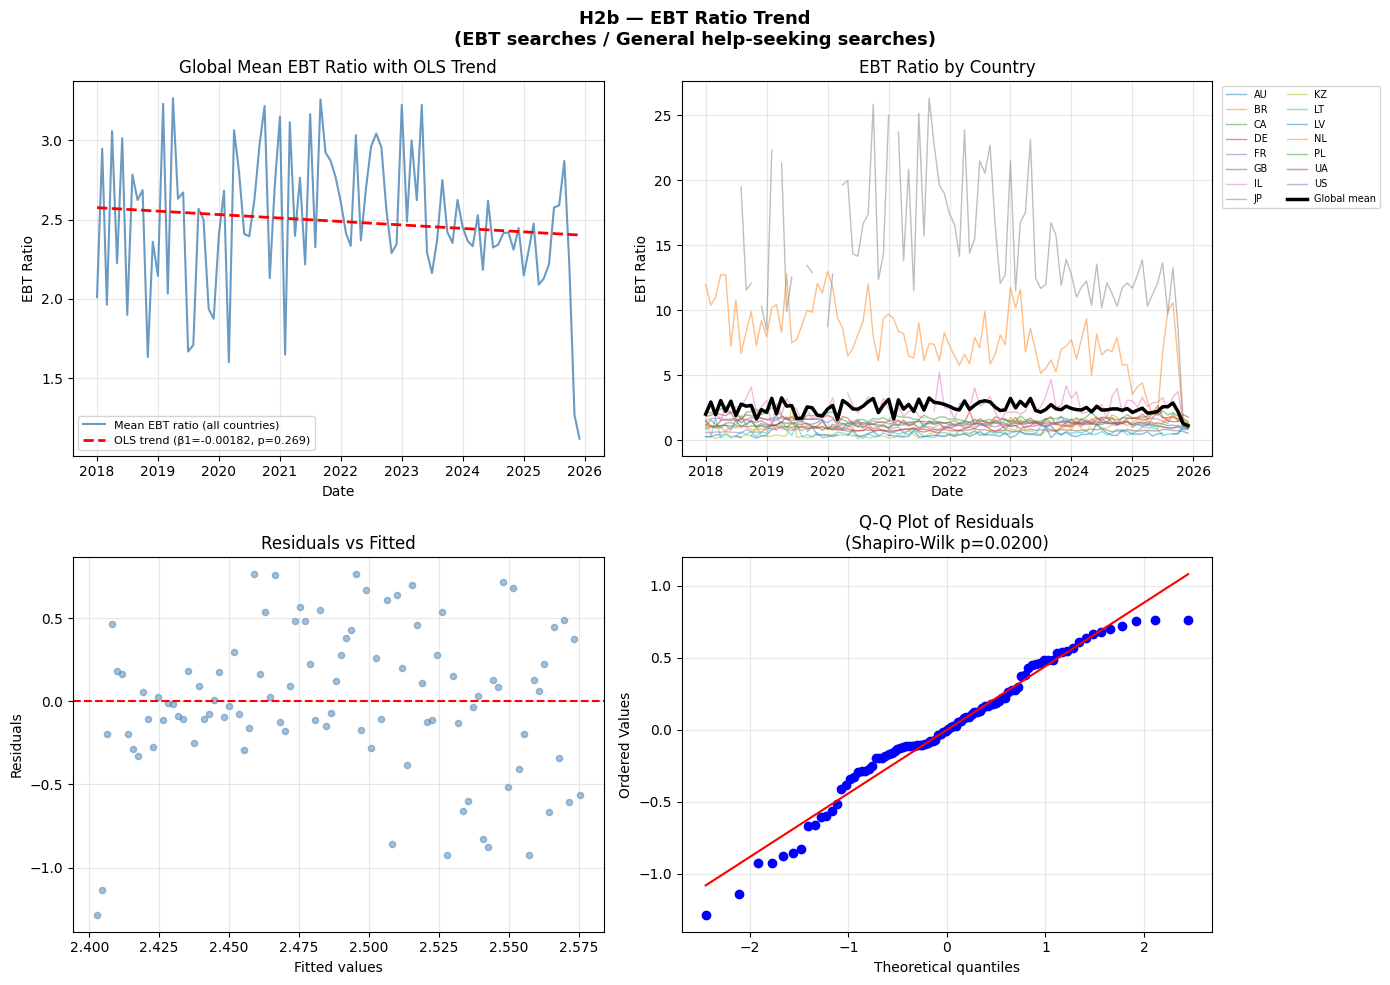

Figure saved to ..\results\H2b\H2b_EBT_ratio_trend.png


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('H2b — EBT Ratio Trend\n(EBT searches / General help-seeking searches)',
             fontsize=13, fontweight='bold')

# ── Plot 1: Global mean EBT ratio with OLS trend ────────────────────────────────
ax1 = axes[0, 0]
ax1.plot(y_global.index, y_global.values, color='steelblue',
         linewidth=1.5, alpha=0.8, label='Mean EBT ratio (all countries)')
y_fit = beta0 + beta1 * t
ax1.plot(y_global.index, y_fit, color='red', linewidth=2,
         linestyle='--', label=f'OLS trend (β1={beta1:.5f}, p={p_val:.3f})')
ax1.set_title('Global Mean EBT Ratio with OLS Trend')
ax1.set_xlabel('Date')
ax1.set_ylabel('EBT Ratio')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# ── Plot 2: EBT ratio by country ────────────────────────────────────────────────
ax2 = axes[0, 1]
for col in panel_ratio.columns:
    ax2.plot(panel_ratio.index, panel_ratio[col], linewidth=1, alpha=0.5, label=col)
ax2.plot(y_global.index, y_global.values, color='black',
         linewidth=2.5, label='Global mean', zorder=5)
ax2.set_title('EBT Ratio by Country')
ax2.set_xlabel('Date')
ax2.set_ylabel('EBT Ratio')
ax2.legend(fontsize=7, ncol=2, bbox_to_anchor=(1.01, 1), loc='upper left')
ax2.grid(alpha=0.3)
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# ── Plot 3: Residuals vs Fitted ─────────────────────────────────────────────────
ax3 = axes[1, 0]
ax3.scatter(model.fittedvalues, residuals, alpha=0.5, color='steelblue', s=20)
ax3.axhline(0, color='red', linestyle='--')
ax3.set_title('Residuals vs Fitted')
ax3.set_xlabel('Fitted values')
ax3.set_ylabel('Residuals')
ax3.grid(alpha=0.3)

# ── Plot 4: Q-Q plot ────────────────────────────────────────────────────────────
ax4 = axes[1, 1]
stats.probplot(residuals, dist='norm', plot=ax4)
ax4.set_title(f'Q-Q Plot of Residuals\n(Shapiro-Wilk p={sw_p:.4f})')
ax4.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'H2b_EBT_ratio_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved to {OUTPUT_DIR / "H2b_EBT_ratio_trend.png"}')

## 7. Export results

In [17]:
results = {
    'hypothesis': 'H2b',
    'outcome': 'EBT_ratio = mean(EBT) / mean(general_help_seeking)',
    'n_months': int(len(y_ols)),
    'n_countries': int(panel_ratio.shape[1]),
    # Two exclusion dicts merged: countries missing data + countries with ratio > 20% missing
    'excluded_countries': {**missing_report, **ratio_missing},

    'ols': {
        'beta0': round(float(beta0), 6),
        'beta1': round(float(beta1), 6),
        'beta1_ci_lower': round(float(ci[1][0]), 6),
        'beta1_ci_upper': round(float(ci[1][1]), 6),
        'p_value': round(float(p_val), 4),
        'r_squared': round(float(r2), 4),
        'significant': bool(p_val < ALPHA_BONF and beta1 > 0),
    },
    'assumptions': {
        'shapiro_wilk_stat': round(float(sw_stat), 4),
        'shapiro_wilk_p': round(float(sw_p), 4),
        'normality_ok': bool(normality_ok),
        'breusch_pagan_stat': round(float(bp_stat), 4),
        'breusch_pagan_p': round(float(bp_p), 4),
        'homoscedasticity_ok': bool(homoscedasticity_ok),
        'assumptions_met': bool(assumptions_ok),
    },
    'mann_kendall': {
        'trend': mk_result.trend,
        'tau': round(float(mk_result.Tau), 4),
        'p_value': round(float(mk_result.p), 4),
        'z': round(float(mk_result.z), 4),
        'significant': bool(mk_result.p < ALPHA_BONF and mk_result.trend == 'increasing'),
    },
    'primary_method': 'OLS' if assumptions_ok else 'Mann-Kendall',
    'alpha_bonferroni': ALPHA_BONF,
}

results_path = OUTPUT_DIR / 'H2b_results.json'
with open(results_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

df_export = pd.DataFrame({'date': y_global.index, 'ebt_ratio_global_mean': y_global.values})
df_export.to_csv(OUTPUT_DIR / 'H2b_monthly_ratio.csv', index=False)

print('Results saved:')
print(f'  {results_path}')
print(f'  {OUTPUT_DIR / "H2b_monthly_ratio.csv"}')
print()
print('═' * 50)
print('SUMMARY')
print('═' * 50)
print(f'Primary method: {results["primary_method"]}')
if results['primary_method'] == 'OLS':
    r = results['ols']
    print(f'β1 = {r["beta1"]}, p = {r["p_value"]}, R² = {r["r_squared"]}')
    print(f'H2b: {"SUPPORTED" if r["significant"] else "NOT SUPPORTED"}')
else:
    r = results['mann_kendall']
    print(f'τ = {r["tau"]}, p = {r["p_value"]}, trend = {r["trend"]}')
    print(f'H2b: {"SUPPORTED" if r["significant"] else "NOT SUPPORTED"}')


Results saved:
  ..\results\H2b\H2b_results.json
  ..\results\H2b\H2b_monthly_ratio.csv

══════════════════════════════════════════════════
SUMMARY
══════════════════════════════════════════════════
Primary method: Mann-Kendall
τ = -0.1035, p = 0.136, trend = no trend
H2b: NOT SUPPORTED
